In [34]:
%matplotlib ipympl
import numpy as np
import xarray as xr
from pathlib import Path
import re
import tifffile
from tqdm.auto import tqdm
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from mpl_interactions import hyperslicer

In [45]:
def load_experiment(path, zarr_output="image_data.zarr", batch=None):
    path = Path(path)
    raman_path = path / "raman"
    tiff_folder = path

    # --- Get image dimensions from first tiff ---
    sample_tiff = next(tiff_folder.glob("*.tiff"), None)
    if sample_tiff is None:
        raise FileNotFoundError(f"No tiff files found in {tiff_folder}")
    sample_img = tifffile.imread(sample_tiff)
    img_y, img_x = sample_img.shape[-2:]

    # ── RAMAN ──────────────────────────────────────────────────────────────────
    data_pat = re.compile(r"raman_p(\d+)_t(\d+)_z(\d+)_data\.npy")
    loc_pat  = re.compile(r"raman_p(\d+)_t(\d+)_z(\d+)_locations\.npy")
    meta_pat = re.compile(r"raman_p(\d+)_t(\d+)_z(\d+)_meta\.json")
    data_files = sorted(f for f in raman_path.glob("*_data.npy") if data_pat.search(f.name))

    if not data_files:
        raise FileNotFoundError(f"No *_data.npy files found in {raman_path}")

    if batch is None:
        sample = np.load(data_files[0])
        batch = sample.squeeze().ndim == 1

    records, index = [], []
    for file in tqdm(data_files, desc="spectra"):
        p, t, z = map(int, data_pat.search(file.name).groups())
        spec = np.load(file)
        if batch:
            records.append(spec.squeeze())
            index.append((t, p, z, 0))
        else:
            for pt, acc_spec in enumerate(spec):
                records.append(acc_spec)
                index.append((t, p, z, pt))

    df = pd.DataFrame(records, index=pd.MultiIndex.from_tuples(index, names=["t", "p", "z", "pt"]))

    records_locs, index_locs = [], []
    for file in tqdm(sorted(raman_path.glob("*_locations.npy")), desc="locations"):
        match = loc_pat.search(file.name)
        if not match:
            continue
        p, t, z = map(int, match.groups())
        coords = np.load(file) * [img_x, img_y]  # use actual image dimensions
        for pt, row in enumerate(coords):
            index_locs.append((t, p, z, pt))
            records_locs.append(row)

    df_locs = pd.DataFrame(
        records_locs,
        index=pd.MultiIndex.from_tuples(index_locs, names=["t", "p", "z", "pt"]),
        columns=["X", "Y"],
    )

    if batch:
        loc_summary = df_locs.groupby(level=["t", "p", "z"]).agg(
            X=("X", "mean"),
            Y=("Y", "mean"),
        ).assign(pt=0).reset_index().set_index(["t", "p", "z", "pt"])
        df = df.merge(loc_summary, left_index=True, right_index=True)
    else:
        df = df.merge(df_locs, left_index=True, right_index=True)

    time_dict = {}
    for file in raman_path.glob("*_meta.json"):
        match = meta_pat.search(file.name)
        if not match:
            continue
        p, t, z = map(int, match.groups())
        with open(file) as f:
            meta = json.load(f)
        time_dict[(t, p, z)] = pd.to_datetime(meta["time"])

    df["time"] = df.index.droplevel("pt").map(time_dict)

    # ── TIFF → ZARR ────────────────────────────────────────────────────────────
    max_p = df.index.get_level_values("p").max()  # derived from raman data

    tiff_pat = re.compile(r"t(\d+)_p(\d+)_c(\d+)_z(\d+)\.tiff")
    tiff_records, tiff_coords = [], []
    for file in tqdm(sorted(tiff_folder.glob("*.tiff")), desc="tiffs"):
        if (match := tiff_pat.search(file.name)):
            t, p, c, z = map(int, match.groups())
            tiff_records.append(tifffile.imread(file))
            tiff_coords.append((t, p, c, z))

    tiff_coords = np.array(tiff_coords)
    t_vals = np.unique(tiff_coords[:, 0])
    p_vals = np.unique(tiff_coords[:, 1])
    c_vals = np.unique(tiff_coords[:, 2])
    z_vals = np.unique(tiff_coords[:, 3])

    full_p_range = np.arange(0, max_p + 1)

    def nearest_p(p, known):
        idx = np.searchsorted(known, p, side='right') - 1
        return known[np.clip(idx, 0, len(known) - 1)]

    p_fill = {p: nearest_p(p, p_vals) for p in full_p_range}

    coord_index = {
        "t": {v: i for i, v in enumerate(t_vals)},
        "p": {v: i for i, v in enumerate(p_vals)},
        "c": {v: i for i, v in enumerate(c_vals)},
        "z": {v: i for i, v in enumerate(z_vals)},
    }

    arr_known = np.zeros((len(t_vals), len(p_vals), len(c_vals), len(z_vals), img_y, img_x), dtype=tiff_records[0].dtype)
    for (t, p, c, z), img in zip(tiff_coords, tiff_records):
        arr_known[
            coord_index["t"][t],
            coord_index["p"][p],
            coord_index["c"][c],
            coord_index["z"][z],
        ] = img

    arr = np.stack(
        [arr_known[:, coord_index["p"][p_fill[p]], :, :, :, :] for p in full_p_range],
        axis=1
    )

    da = xr.DataArray(
        arr,
        dims=["t", "p", "c", "z", "y", "x"],
        coords={"t": t_vals, "p": full_p_range, "c": c_vals, "z": z_vals},
        name="image"
    )

    da.to_dataset().to_zarr(zarr_output, mode="w")
    print(f"Saved Zarr to {zarr_output}")

    return df, df_locs, da

In [47]:
folder = 'testing'
n = 9
df, df_locs, da = load_experiment(f"{folder}/data/run_{n}", zarr_output=f'ds_run_{n}.zarr')

spectra:   0%|          | 0/8 [00:00<?, ?it/s]

locations:   0%|          | 0/8 [00:00<?, ?it/s]

tiffs:   0%|          | 0/8 [00:00<?, ?it/s]

Saved Zarr to ds_run_9.zarr


In [49]:
bf = da.sel(c=0).values

C:\Users\Rayleigh\AppData\Local\Temp\ipykernel_11492\4293737538.py:18: PerformanceWarning: indexing past lexsort depth may impact performance.
  sub = df.loc[t0, p0, z0]


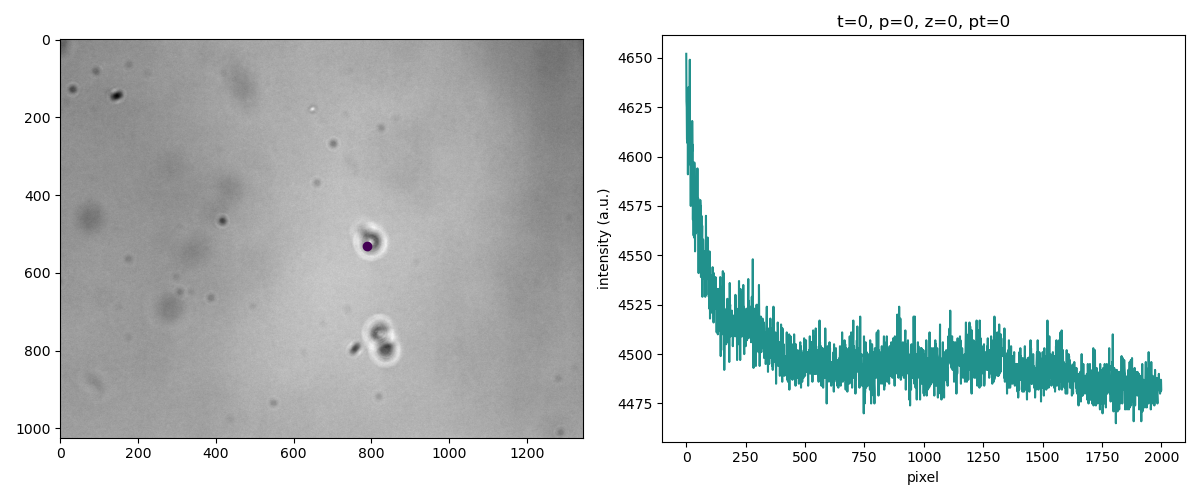

In [51]:
# --- Side-by-side figure ---
fig, (ax_img, ax_spec) = plt.subplots(1, 2, figsize=(12, 5))

controls = hyperslicer(bf, cmap='gray', ax=ax_img, names=("t", "p", "z"))

t0, p0, z0 = 0, 0, 0
pt_selected = {"pt": 0}

cmap = cm.viridis

def pt_colors(n):
    """Viridis colors for n points, indexed 0..n-1."""
    if n <= 1:
        return cmap(np.array([0.5]))
    return cmap(np.linspace(0, 1, n))

# Initial scatter
sub = df.loc[t0, p0, z0]
n0 = len(sub)
scat = ax_img.scatter(sub['Y'], sub['X'],
                      c=np.arange(n0), cmap=cmap,
                      vmin=0, vmax=max(n0 - 1, 1),
                      picker=5)

# Initial spectrum (color-matched to pt=0)
spec0 = df.loc[t0, p0, z0, pt_selected["pt"]].values[:-3]
init_color = pt_colors(n0)[pt_selected["pt"]]
(line,) = ax_spec.plot(spec0, color=init_color)
ax_spec.set_xlabel("pixel")
ax_spec.set_ylabel("intensity (a.u.)")
ax_spec.set_title(f"t={t0}, p={p0}, z={z0}, pt={pt_selected['pt']}")


def current_tpz():
    return (int(controls.params["t"]),
            int(controls.params["p"]),
            int(controls.params["z"]))


def update_scatter(**kwargs):
    t, p, z = current_tpz()
    try:
        sub = df.loc[t, p, z]
    except KeyError:
        scat.set_offsets(np.empty((0, 2)))
        fig.canvas.draw_idle()
        return

    n = len(sub)
    scat.set_offsets(np.c_[sub['Y'].to_numpy(), sub['X'].to_numpy()])
    scat.set_array(np.arange(n))
    scat.set_clim(0, max(n - 1, 1))
    fig.canvas.draw_idle()
    update_spectrum()


def update_spectrum():
    t, p, z = current_tpz()
    pt = pt_selected["pt"]
    try:
        y = df.loc[t, p, z, pt].values[:-3]
        n = len(df.loc[t, p, z])
    except KeyError:
        return
    line.set_ydata(y)
    line.set_color(pt_colors(n)[min(pt, n - 1)])
    ax_spec.relim()
    ax_spec.autoscale_view()
    ax_spec.set_title(f"t={t}, p={p}, z={z}, pt={pt}")
    fig.canvas.draw_idle()


def on_pick(event):
    if event.artist is not scat:
        return
    pt_selected["pt"] = int(event.ind[0])
    update_spectrum()


for name in ("t", "p", "z"):
    controls.register_callback(update_scatter, name)

fig.canvas.mpl_connect("pick_event", on_pick)

fig.tight_layout()
plt.show()